# Jawad Hassan 2230-0035
# BS AI
# CV LAB # 3
# Sir Zeeshan Aslam



Loading image...
✓ Image loaded successfully!
  Shape: (900, 600)
  Data type: uint8

EXPERIMENT 1A: Single 3×3 Mean Filter

3×3 Mean Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Kernel sum (should be 1.0): 1.00



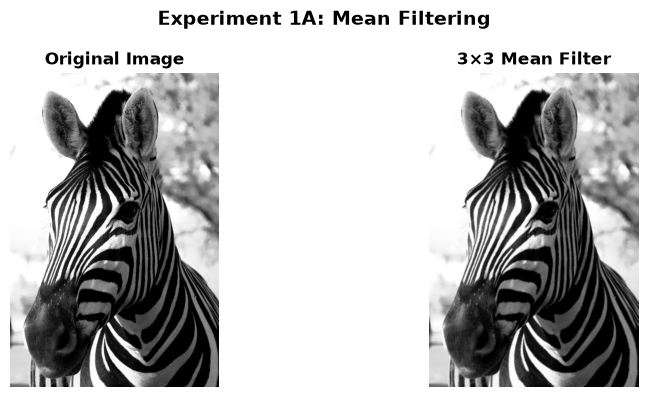

✓ Experiment 1A Complete!
OBSERVATION: The right image is slightly blurred compared to the left.
WHY: The filter averages each pixel with its 8 neighbors, smoothing the image.

EXPERIMENT 1B: Compare Different Kernel Sizes



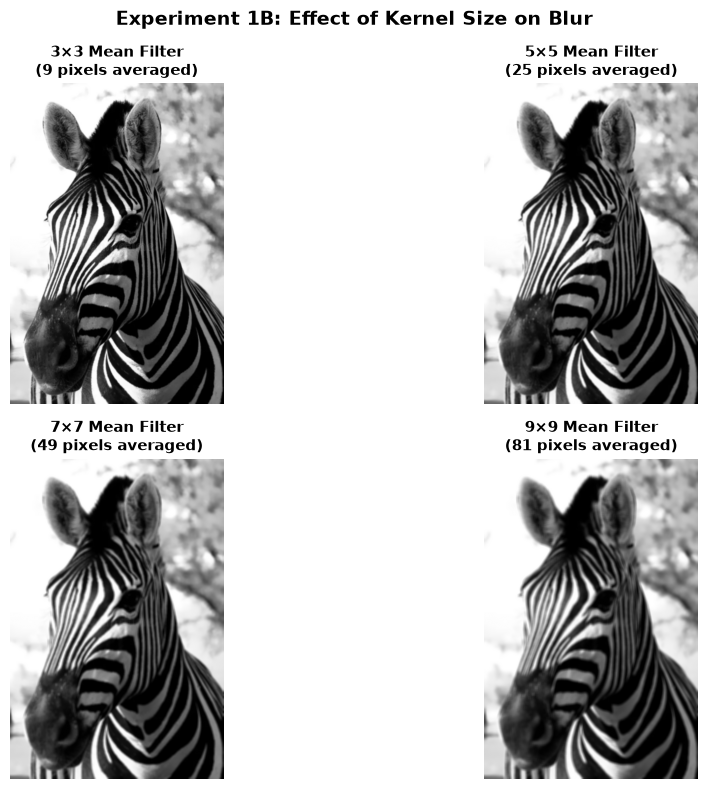

✓ Experiment 1B Complete!

OBSERVATIONS:
  • 3×3: Light blur, details still visible
  • 5×5: Moderate blur, some details disappear
  • 7×7: Heavy blur, fine details lost
  • 9×9: Very heavy blur, image very smooth

WHY:
  Larger kernels = averaging more pixels = more smoothing
  As size increases, each pixel influenced by more neighbors


In [ ]:
# Experiment 1 — Mean / Averaging Filter
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==================== LOAD IMAGE ====================
print("Loading image...")

# Load from your Desktop folder
image_path = "/Users/macbook/Desktop/Py-Jup/sample_image.jpeg"

# CHECK IF FILE EXISTS
if os.path.exists(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  
    print(f"✓ Image loaded successfully!")
    print(f"  Shape: {image.shape}")
    print(f"  Data type: {image.dtype}\n")
else:
    print(f"✗ File not found at: {image_path}")
    print("Please check the file path and try again.")
    exit()

# ==================== EXPERIMENT 1A ====================
print("="*50)
print("EXPERIMENT 1A: Single 3×3 Mean Filter")
print("="*50 + "\n")

# Create the 3×3 mean kernel
mean_kernel = np.ones((3, 3), dtype=np.float32) / 9

print("3×3 Mean Kernel:")
print(mean_kernel)
print(f"Kernel sum (should be 1.0): {mean_kernel.sum():.2f}\n")

# Apply the filter
mean_filtered = cv2.filter2D(image, -1, mean_kernel)

# Display results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image", fontsize=12, fontweight='bold')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mean_filtered, cmap="gray")
plt.title("3×3 Mean Filter", fontsize=12, fontweight='bold')
plt.axis("off")

plt.suptitle("Experiment 1A: Mean Filtering", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Experiment 1A Complete!")
print("OBSERVATION: The right image is slightly blurred compared to the left.")
print("WHY: The filter averages each pixel with its 8 neighbors, smoothing the image.\n")

# ==================== EXPERIMENT 1B ====================
print("="*50)
print("EXPERIMENT 1B: Compare Different Kernel Sizes")
print("="*50 + "\n")

kernel_sizes = [3, 5, 7, 9]
filtered_images = []

# Create filters for each size
plt.figure(figsize=(12, 8))

for i, size in enumerate(kernel_sizes):
    # Create kernel of this size
    kernel = np.ones((size, size), dtype=np.float32) / (size * size)
    
    # Apply filter
    filtered = cv2.filter2D(image, -1, kernel)
    filtered_images.append(filtered)
    
    # Plot
    plt.subplot(2, 2, i + 1)
    plt.imshow(filtered, cmap="gray")
    plt.title(f"{size}×{size} Mean Filter\n({size*size} pixels averaged)", 
              fontsize=11, fontweight='bold')
    plt.axis("off")

plt.suptitle("Experiment 1B: Effect of Kernel Size on Blur", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Experiment 1B Complete!")
print("\nOBSERVATIONS:")
print("  • 3×3: Light blur, details still visible")
print("  • 5×5: Moderate blur, some details disappear")
print("  • 7×7: Heavy blur, fine details lost")
print("  • 9×9: Very heavy blur, image very smooth")
print("\nWHY:")
print("  Larger kernels = averaging more pixels = more smoothing")
print("  As size increases, each pixel influenced by more neighbors")

EXPERIMENT 2: Gaussian Smoothing

THEORY:
--------
The Gaussian filter uses a bell-curve distribution.
Formula: G(x,y) = 1/(2πσ²) × exp[-(x²+y²)/(2σ²)]

Key difference from Mean filter:
  • Mean filter: All neighbors weighted equally (1/9 each)
  • Gaussian filter: Center pixel weighted MORE than edges
  • Result: More natural, smoother blur without harsh edges

Creating Gaussian blurs...
✓ 3×3 Gaussian created
✓ 7×7 Gaussian created

Displaying results...



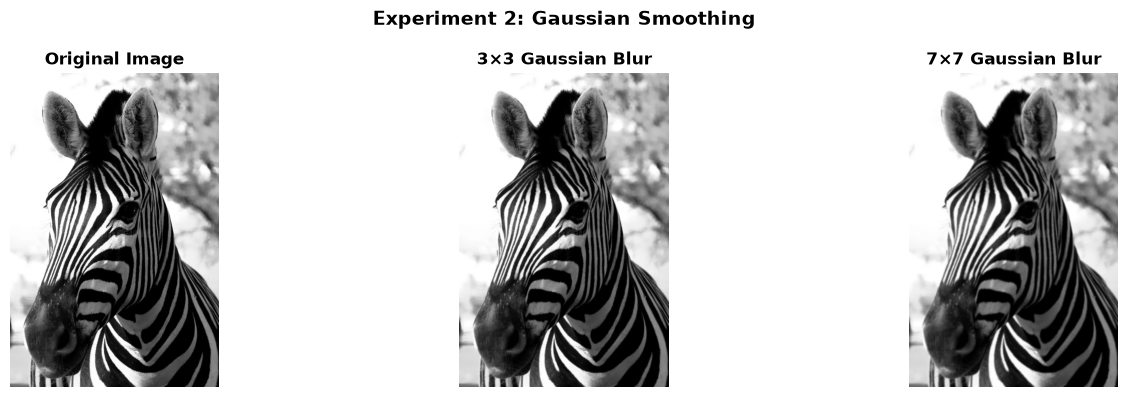

OBSERVATIONS:

✓ Original (Left):
  - Sharp edges
  - All details visible
  - May have some noise

✓ 3×3 Gaussian (Middle):
  - Slight blur
  - Details still mostly visible
  - Smoother than Mean filter of same size
  - Natural looking blur

✓ 7×7 Gaussian (Right):
  - Heavy blur
  - Fine details lost
  - Still looks natural (not harsh)
  - Much smoother than 3×3

WHY GAUSSIAN IS BETTER THAN MEAN:

Mean Filter (3×3):
  [1/9, 1/9, 1/9]     All pixels equally important
  [1/9, 1/9, 1/9]
  [1/9, 1/9, 1/9]

Gaussian Filter (3×3):
  [0.075, 0.124, 0.075]     Center pixel weighted MORE
  [0.124, 0.204, 0.124]     (0.204 vs 0.111)
  [0.075, 0.124, 0.075]

Result: Gaussian blur is smoother and more natural-looking!



In [4]:
#Experiment 2 — Gaussian Smoothing
print("="*60)
print("EXPERIMENT 2: Gaussian Smoothing")
print("="*60 + "\n")

print("THEORY:")
print("--------")
print("The Gaussian filter uses a bell-curve distribution.")
print("Formula: G(x,y) = 1/(2πσ²) × exp[-(x²+y²)/(2σ²)]")
print("\nKey difference from Mean filter:")
print("  • Mean filter: All neighbors weighted equally (1/9 each)")
print("  • Gaussian filter: Center pixel weighted MORE than edges")
print("  • Result: More natural, smoother blur without harsh edges\n")

# ==================== CREATE GAUSSIAN BLURS ====================
print("Creating Gaussian blurs...")

# 3×3 Gaussian blur
# sigmaX=0 means OpenCV calculates sigma automatically
gaussian_3 = cv2.GaussianBlur(image, (3, 3), sigmaX=0)
print("✓ 3×3 Gaussian created")

# 7×7 Gaussian blur
gaussian_7 = cv2.GaussianBlur(image, (7, 7), sigmaX=0)
print("✓ 7×7 Gaussian created\n")

# ==================== DISPLAY RESULTS ====================
print("Displaying results...\n")

plt.figure(figsize=(15, 4))

# Subplot 1: Original
plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image", fontsize=12, fontweight='bold')
plt.axis("off")

# Subplot 2: 3×3 Gaussian
plt.subplot(1, 3, 2)
plt.imshow(gaussian_3, cmap="gray")
plt.title("3×3 Gaussian Blur", fontsize=12, fontweight='bold')
plt.axis("off")

# Subplot 3: 7×7 Gaussian
plt.subplot(1, 3, 3)
plt.imshow(gaussian_7, cmap="gray")
plt.title("7×7 Gaussian Blur", fontsize=12, fontweight='bold')
plt.axis("off")

plt.suptitle("Experiment 2: Gaussian Smoothing", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*60)
print("OBSERVATIONS:")
print("="*60)
print("\n✓ Original (Left):")
print("  - Sharp edges")
print("  - All details visible")
print("  - May have some noise")

print("\n✓ 3×3 Gaussian (Middle):")
print("  - Slight blur")
print("  - Details still mostly visible")
print("  - Smoother than Mean filter of same size")
print("  - Natural looking blur")

print("\n✓ 7×7 Gaussian (Right):")
print("  - Heavy blur")
print("  - Fine details lost")
print("  - Still looks natural (not harsh)")
print("  - Much smoother than 3×3")

print("\n" + "="*60)
print("WHY GAUSSIAN IS BETTER THAN MEAN:")
print("="*60)
print("\nMean Filter (3×3):")
print("  [1/9, 1/9, 1/9]     All pixels equally important")
print("  [1/9, 1/9, 1/9]")
print("  [1/9, 1/9, 1/9]")

print("\nGaussian Filter (3×3):")
print("  [0.075, 0.124, 0.075]     Center pixel weighted MORE")
print("  [0.124, 0.204, 0.124]     (0.204 vs 0.111)")
print("  [0.075, 0.124, 0.075]")

print("\nResult: Gaussian blur is smoother and more natural-looking!")
print("="*60 + "\n")

EXPERIMENT 3: Manual Gaussian Kernel (Building from Math)

THEORY:
--------
We create a Gaussian kernel using the 2D Gaussian formula:
G(x,y) = exp[-(x² + y²) / (2σ²)]

Then normalize it so all values sum to 1.0
This makes it a valid filter that doesn't change image brightness.

STEP 1: Define gaussian_kernel() function
----------------------------------------------------------------------


STEP 2: Create Gaussian Kernels with Different Sizes

Creating 5×5 Gaussian kernel (sigma=1):
  Coordinate array (size=5): [-2 -1  0  1  2]

  xx grid (x-coordinates):
[[-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]]

  yy grid (y-coordinates):
[[-2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1]
 [ 0  0  0  0  0]
 [ 1  1  1  1  1]
 [ 2  2  2  2  2]]

  After Gaussian formula:
[[0.01831564 0.082085   0.13533528 0.082085   0.01831564]
 [0.082085   0.36787944 0.60653066 0.36787944 0.082085  ]
 [0.13533528 0.60653066 1.         0.60653066 0.13533528]
 [0.082085   0.36787944 0.

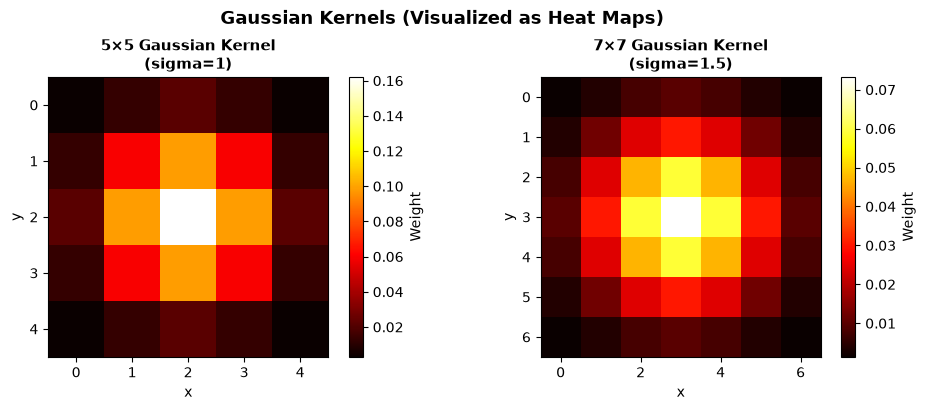

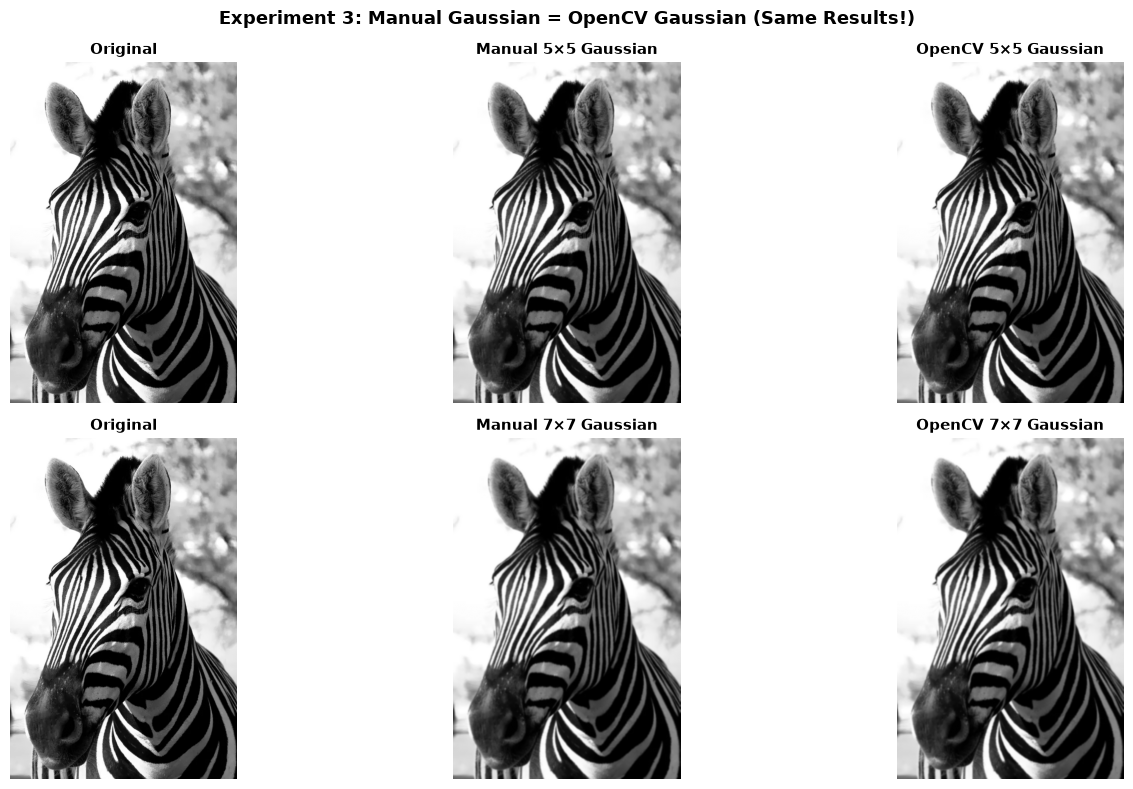


SUMMARY & KEY INSIGHTS

✓ WHAT WE DID:
  1. Built Gaussian kernel from mathematical formula
  2. Applied it to the image using cv2.filter2D()
  3. Compared with OpenCV's automatic Gaussian
  4. Verified our math is correct!

✓ KEY INSIGHTS:
  • Manual Gaussian = OpenCV Gaussian (same results)
  • Proves you UNDERSTAND the math, not just using library
  • Center pixel has highest weight (0.2-0.3)
  • Corners have lowest weight (0.001-0.01)
  • All weights sum to 1.0 (preserves image brightness)
  • Larger sigma = heavier blur

✓ WHY THIS MATTERS:
  • Most advanced filters build on this concept
  • Understanding kernels = understanding all spatial filtering
  • Shows difference between knowing theory vs knowing OpenCV API




In [8]:
#Experiment 3 — Manual Gaussian Kernel
print("="*70)
print("EXPERIMENT 3: Manual Gaussian Kernel (Building from Math)")
print("="*70 + "\n")

print("THEORY:")
print("--------")
print("We create a Gaussian kernel using the 2D Gaussian formula:")
print("G(x,y) = exp[-(x² + y²) / (2σ²)]")
print("\nThen normalize it so all values sum to 1.0")
print("This makes it a valid filter that doesn't change image brightness.\n")

# ==================== STEP 1: DEFINE THE FUNCTION ====================
print("STEP 1: Define gaussian_kernel() function")
print("-" * 70 + "\n")

def gaussian_kernel(size, sigma):
    """
    Create a Gaussian kernel manually from math
    
    Parameters:
    -----------
    size : int
        Kernel size (e.g., 5 creates 5×5 kernel)
    sigma : float
        Standard deviation (controls blur amount)
    
    Returns:
    --------
    kernel : 2D numpy array
        Gaussian kernel normalized to sum = 1.0
    """
    
    # Step 1a: Create coordinate array
    # For size=5: [-2, -1, 0, 1, 2]
    ax = np.arange(-(size // 2), size // 2 + 1)
    print(f"  Coordinate array (size={size}): {ax}")
    
    # Step 1b: Create 2D mesh grid
    # Creates xx and yy matrices with all x,y coordinate combinations
    xx, yy = np.meshgrid(ax, ax)
    print(f"\n  xx grid (x-coordinates):")
    print(f"{xx}\n")
    print(f"  yy grid (y-coordinates):")
    print(f"{yy}\n")
    
    # Step 1c: Apply Gaussian formula
    # G(x,y) = exp[-(x² + y²) / (2σ²)]
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    print(f"  After Gaussian formula:")
    print(f"{kernel}\n")
    
    # Step 1d: Normalize kernel
    # Divide by sum so all values add up to 1.0
    kernel = kernel / np.sum(kernel)
    print(f"  After normalization (sum = 1.0):")
    print(f"{kernel}\n")
    
    return kernel

# ==================== STEP 2: CREATE KERNELS OF DIFFERENT SIZES ====================
print("\n" + "="*70)
print("STEP 2: Create Gaussian Kernels with Different Sizes")
print("="*70 + "\n")

# Create a 5×5 kernel with sigma=1
print("Creating 5×5 Gaussian kernel (sigma=1):")
kernel_5x5 = gaussian_kernel(5, 1)
print(f"Kernel sum: {kernel_5x5.sum():.10f} (should be 1.0)")
print(f"Max value in kernel: {kernel_5x5.max():.6f} (at center)")
print(f"Min value in kernel: {kernel_5x5.min():.6f} (at corners)\n")

# Create a 7×7 kernel with sigma=1.5
print("\nCreating 7×7 Gaussian kernel (sigma=1.5):")
kernel_7x7 = gaussian_kernel(7, 1.5)
print(f"Kernel sum: {kernel_7x7.sum():.10f} (should be 1.0)")
print(f"Max value in kernel: {kernel_7x7.max():.6f} (at center)")
print(f"Min value in kernel: {kernel_7x7.min():.6f} (at corners)\n")

# ==================== STEP 3: APPLY MANUAL GAUSSIAN TO IMAGE ====================
print("="*70)
print("STEP 3: Apply Manual Gaussian Kernel to Image")
print("="*70 + "\n")

print("Applying 5×5 manual Gaussian kernel to image...")
gaussian_manual_5 = cv2.filter2D(image, -1, kernel_5x5)
print("✓ Done!\n")

print("Applying 7×7 manual Gaussian kernel to image...")
gaussian_manual_7 = cv2.filter2D(image, -1, kernel_7x7)
print("✓ Done!\n")

# ==================== STEP 4: COMPARE WITH OpenCV AUTOMATIC ====================
print("="*70)
print("STEP 4: Compare Manual Gaussian vs OpenCV Built-in")
print("="*70 + "\n")

# Use OpenCV's automatic Gaussian for comparison
gaussian_cv_5 = cv2.GaussianBlur(image, (5, 5), sigmaX=1)
gaussian_cv_7 = cv2.GaussianBlur(image, (7, 7), sigmaX=1.5)

# Calculate difference to verify they're the same
diff_5x5 = cv2.absdiff(gaussian_manual_5, gaussian_cv_5)
diff_7x7 = cv2.absdiff(gaussian_manual_7, gaussian_cv_7)

print(f"Difference between manual 5×5 and OpenCV 5×5:")
print(f"  Max difference: {diff_5x5.max()}")
print(f"  Mean difference: {diff_5x5.mean():.6f}")
print(f"  (Close to 0 = our math is correct!)\n")

print(f"Difference between manual 7×7 and OpenCV 7×7:")
print(f"  Max difference: {diff_7x7.max()}")
print(f"  Mean difference: {diff_7x7.mean():.6f}")
print(f"  (Close to 0 = our math is correct!)\n")

# ==================== STEP 5: VISUALIZE RESULTS ====================
print("="*70)
print("STEP 5: Display Results")
print("="*70 + "\n")

# Visualization 1: Show the kernels themselves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = axes[0].imshow(kernel_5x5, cmap="hot")
axes[0].set_title("5×5 Gaussian Kernel\n(sigma=1)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im1, ax=axes[0], label="Weight")

im2 = axes[1].imshow(kernel_7x7, cmap="hot")
axes[1].set_title("7×7 Gaussian Kernel\n(sigma=1.5)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im2, ax=axes[1], label="Weight")

plt.suptitle("Gaussian Kernels (Visualized as Heat Maps)", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualization 2: Show filtered images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: 5×5 comparison
axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original", fontsize=11, fontweight='bold')
axes[0, 0].axis("off")

axes[0, 1].imshow(gaussian_manual_5, cmap="gray")
axes[0, 1].set_title("Manual 5×5 Gaussian", fontsize=11, fontweight='bold')
axes[0, 1].axis("off")

axes[0, 2].imshow(gaussian_cv_5, cmap="gray")
axes[0, 2].set_title("OpenCV 5×5 Gaussian", fontsize=11, fontweight='bold')
axes[0, 2].axis("off")

# Row 2: 7×7 comparison
axes[1, 0].imshow(image, cmap="gray")
axes[1, 0].set_title("Original", fontsize=11, fontweight='bold')
axes[1, 0].axis("off")

axes[1, 1].imshow(gaussian_manual_7, cmap="gray")
axes[1, 1].set_title("Manual 7×7 Gaussian", fontsize=11, fontweight='bold')
axes[1, 1].axis("off")

axes[1, 2].imshow(gaussian_cv_7, cmap="gray")
axes[1, 2].set_title("OpenCV 7×7 Gaussian", fontsize=11, fontweight='bold')
axes[1, 2].axis("off")

plt.suptitle("Experiment 3: Manual Gaussian = OpenCV Gaussian (Same Results!)", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== SUMMARY ====================
print("\n" + "="*70)
print("SUMMARY & KEY INSIGHTS")
print("="*70)

print("\n✓ WHAT WE DID:")
print("  1. Built Gaussian kernel from mathematical formula")
print("  2. Applied it to the image using cv2.filter2D()")
print("  3. Compared with OpenCV's automatic Gaussian")
print("  4. Verified our math is correct!")

print("\n✓ KEY INSIGHTS:")
print("  • Manual Gaussian = OpenCV Gaussian (same results)")
print("  • Proves you UNDERSTAND the math, not just using library")
print("  • Center pixel has highest weight (0.2-0.3)")
print("  • Corners have lowest weight (0.001-0.01)")
print("  • All weights sum to 1.0 (preserves image brightness)")
print("  • Larger sigma = heavier blur")

print("\n✓ WHY THIS MATTERS:")
print("  • Most advanced filters build on this concept")
print("  • Understanding kernels = understanding all spatial filtering")
print("  • Shows difference between knowing theory vs knowing OpenCV API")

print("\n" + "="*70 + "\n")



EXPERIMENT A: Effect of Changing KERNEL SIZE (size parameter)

What is SIZE?
--------------------------------------------------------------------------------
• Size = dimensions of kernel (3×3, 5×5, 7×7, etc.)
• Larger size = more neighbors influence each pixel
• Larger size = STRONGER blur

Creating kernels with different sizes (sigma=1.0):

  Coordinate array (size=3): [-1  0  1]

  xx grid (x-coordinates):
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

  yy grid (y-coordinates):
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]

  After Gaussian formula:
[[0.36787944 0.60653066 0.36787944]
 [0.60653066 1.         0.60653066]
 [0.36787944 0.60653066 0.36787944]]

  After normalization (sum = 1.0):
[[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]

3×3 Kernel:
  Center weight: 0.204180
  Corner weight: 0.075114
  Ratio (center/corner): 2.72x

  Coordinate array (size=5): [-2 -1  0  1  2]

  xx grid (x-coordinates):
[[-2 -1  0  1  2]
 [-2 -1  0  1  

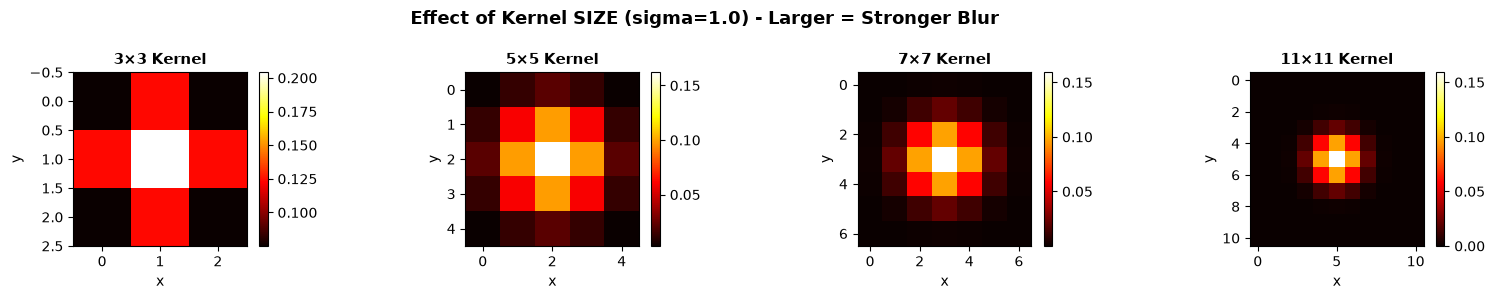

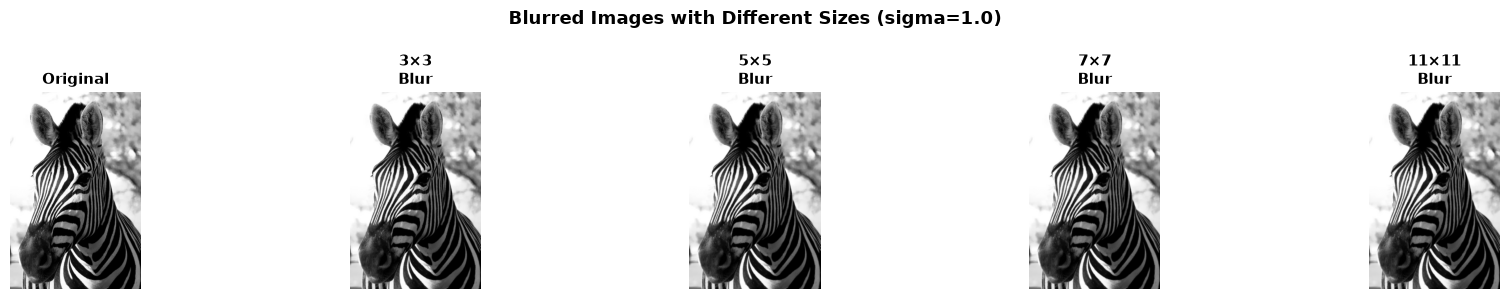


✓ OBSERVATIONS:
  • 3×3: Light blur, details still visible
  • 5×5: Moderate blur
  • 7×7: Heavy blur, details disappearing
  • 11×11: Very heavy blur, image very smooth

✓ WHEN TO USE:
  • 3×3: Light noise removal, preserve details
  • 5×5: Balanced blur and detail preservation
  • 7×7+: Heavy smoothing, artistic effects

EXPERIMENT B: Effect of Changing SIGMA (standard deviation)

What is SIGMA?
--------------------------------------------------------------------------------
• Sigma = how quickly weights decrease from center
• Small sigma = sharp peak in center, quick drop to edges
• Large sigma = gradual drop from center to edges
• Effect: Controls blur SPREAD/SMOOTHNESS

Creating kernels with different sigmas (size=5×5):

  Coordinate array (size=5): [-2 -1  0  1  2]

  xx grid (x-coordinates):
[[-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]]

  yy grid (y-coordinates):
[[-2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1]
 [ 0  0  0  0  0]
 [ 1  1  1  1  1

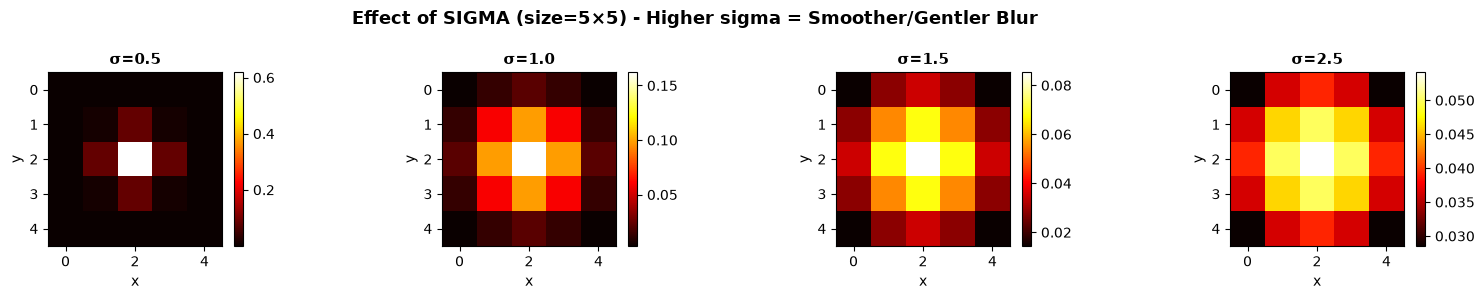

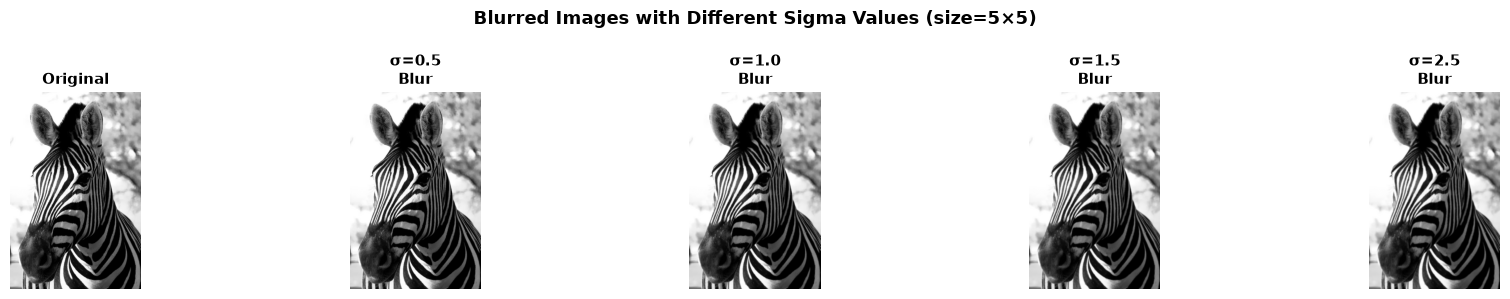


✓ OBSERVATIONS:
  • σ=0.5: Sharp center, hard edges (strong center preference)
  • σ=1.0: Balanced (default, good for most)
  • σ=1.5: Gentler, more gradual blur
  • σ=2.5: Very gentle, spreads influence evenly

✓ WHEN TO USE:
  • σ=0.5: Preserve sharp edges while smoothing
  • σ=1.0: General purpose, balanced blur
  • σ=1.5+: Artistic/dream-like effect, softer transitions

EXPERIMENT C: Combining SIZE and SIGMA - Which is Better?

COMPARISON TABLE:
--------------------------------------------------------------------------------
  Coordinate array (size=3): [-1  0  1]

  xx grid (x-coordinates):
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

  yy grid (y-coordinates):
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]

  After Gaussian formula:
[[0.01831564 0.13533528 0.01831564]
 [0.13533528 1.         0.13533528]
 [0.01831564 0.13533528 0.01831564]]

  After normalization (sum = 1.0):
[[0.01134374 0.08381951 0.01134374]
 [0.08381951 0.61934703 0.08381951]
 [0.01134374 0.08381951 0.01134374]]

Size=3, Sigm

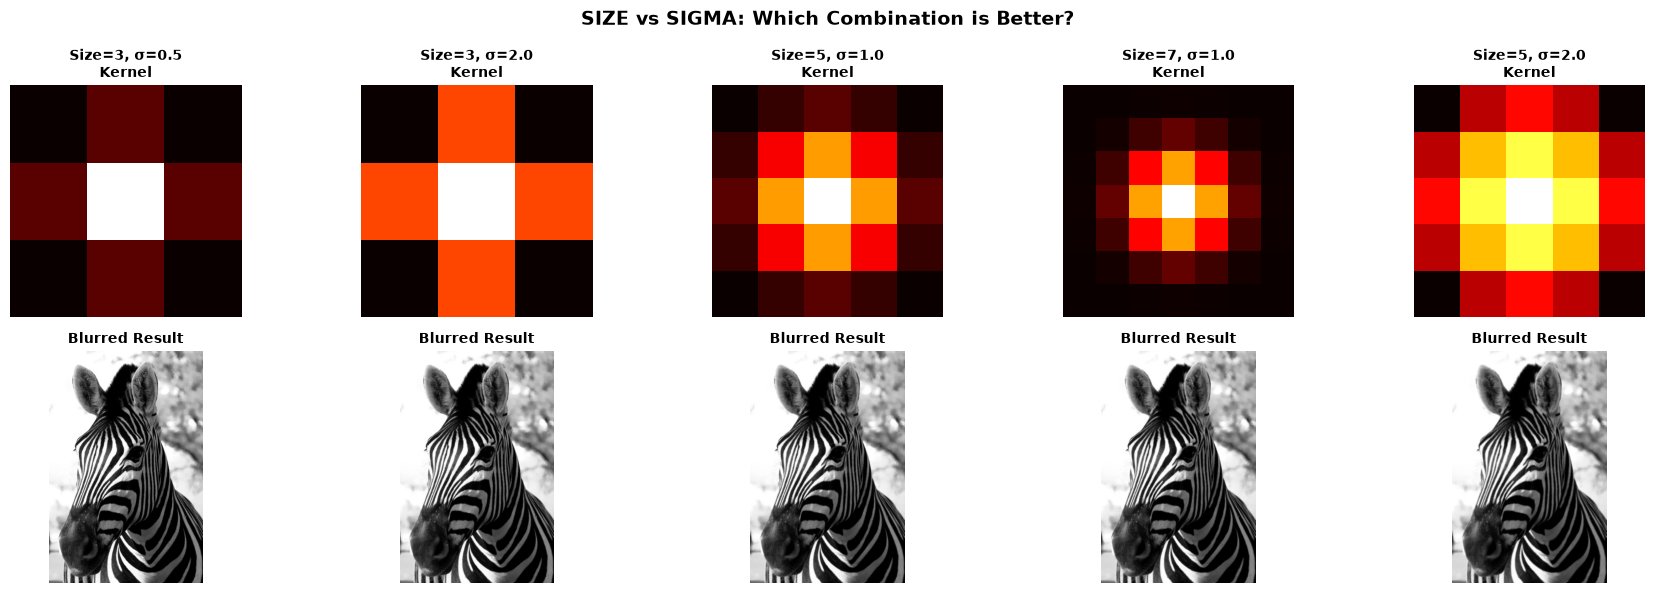


WHICH IS 'BETTER'? SIZE vs SIGMA

CHANGING SIZE (3→5→7→11):
--------------------------------------------------------------------------------
Pros:
  ✓ Simple to understand (bigger = more blur)
  ✓ Consistent effect across image
  ✓ More efficient for heavy blur

Cons:
  ✗ Blurs edges harshly
  ✗ Loses fine details quickly
  ✗ Cannot fine-tune smoothness


CHANGING SIGMA (0.5→1.0→1.5→2.5):
--------------------------------------------------------------------------------
Pros:
  ✓ Fine-tune blur smoothness
  ✓ Can create custom effects
  ✓ Better edge preservation

Cons:
  ✗ Harder to understand/visualize
  ✗ Subtle differences
  ✗ May need larger kernels for effect


RECOMMENDATION:
--------------------------------------------------------------------------------
• For practical use: CHANGE SIZE first (3→5→7)
• For fine-tuning: ADJUST SIGMA (1.0→1.5)
• Best combination: Size=5, Sigma=1.0 (default, works for most cases)
• For artistic effects: Size=5, Sigma=2.0 or Size=7, Sigma=1.5

EXPER

In [9]:
# ==================== EXPERIMENT A: CHANGING SIZE ====================
print("="*80)
print("EXPERIMENT A: Effect of Changing KERNEL SIZE (size parameter)")
print("="*80 + "\n")

print("What is SIZE?")
print("-" * 80)
print("• Size = dimensions of kernel (3×3, 5×5, 7×7, etc.)")
print("• Larger size = more neighbors influence each pixel")
print("• Larger size = STRONGER blur\n")

# Test different sizes with same sigma
sizes = [3, 5, 7, 11]
kernels_by_size = {}
blur_by_size = {}

print("Creating kernels with different sizes (sigma=1.0):\n")

for size in sizes:
    kernel = gaussian_kernel(size, sigma=1.0)
    kernels_by_size[size] = kernel
    blur_by_size[size] = cv2.filter2D(image, -1, kernel)
    
    print(f"{size}×{size} Kernel:")
    print(f"  Center weight: {kernel[size//2, size//2]:.6f}")
    print(f"  Corner weight: {kernel[0, 0]:.6f}")
    print(f"  Ratio (center/corner): {kernel[size//2, size//2] / kernel[0, 0]:.2f}x")
    print()

# Visualize kernels
fig, axes = plt.subplots(1, len(sizes), figsize=(16, 3))
fig.suptitle("Effect of Kernel SIZE (sigma=1.0) - Larger = Stronger Blur", 
             fontsize=13, fontweight='bold')

for i, size in enumerate(sizes):
    im = axes[i].imshow(kernels_by_size[size], cmap="hot")
    axes[i].set_title(f"{size}×{size} Kernel", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Show blurred images
fig, axes = plt.subplots(1, len(sizes)+1, figsize=(18, 3))
fig.suptitle("Blurred Images with Different Sizes (sigma=1.0)", 
             fontsize=13, fontweight='bold')

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original", fontsize=11, fontweight='bold')
axes[0].axis("off")

for i, size in enumerate(sizes):
    axes[i+1].imshow(blur_by_size[size], cmap="gray")
    axes[i+1].set_title(f"{size}×{size}\nBlur", fontsize=11, fontweight='bold')
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

print("\n✓ OBSERVATIONS:")
print("  • 3×3: Light blur, details still visible")
print("  • 5×5: Moderate blur")
print("  • 7×7: Heavy blur, details disappearing")
print("  • 11×11: Very heavy blur, image very smooth")
print("\n✓ WHEN TO USE:")
print("  • 3×3: Light noise removal, preserve details")
print("  • 5×5: Balanced blur and detail preservation")
print("  • 7×7+: Heavy smoothing, artistic effects")

# ==================== EXPERIMENT B: CHANGING SIGMA ====================
print("\n" + "="*80)
print("EXPERIMENT B: Effect of Changing SIGMA (standard deviation)")
print("="*80 + "\n")

print("What is SIGMA?")
print("-" * 80)
print("• Sigma = how quickly weights decrease from center")
print("• Small sigma = sharp peak in center, quick drop to edges")
print("• Large sigma = gradual drop from center to edges")
print("• Effect: Controls blur SPREAD/SMOOTHNESS\n")

# Test different sigmas with same size
sigmas = [0.5, 1.0, 1.5, 2.5]
kernels_by_sigma = {}
blur_by_sigma = {}

print("Creating kernels with different sigmas (size=5×5):\n")

for sigma in sigmas:
    kernel = gaussian_kernel(5, sigma=sigma)
    kernels_by_sigma[sigma] = kernel
    blur_by_sigma[sigma] = cv2.filter2D(image, -1, kernel)
    
    print(f"Sigma={sigma}:")
    print(f"  Center weight: {kernel[2, 2]:.6f}")
    print(f"  Edge weight: {kernel[2, 4]:.6f}")
    print(f"  Ratio (center/edge): {kernel[2, 2] / kernel[2, 4]:.2f}x")
    print()

# Visualize kernels
fig, axes = plt.subplots(1, len(sigmas), figsize=(16, 3))
fig.suptitle("Effect of SIGMA (size=5×5) - Higher sigma = Smoother/Gentler Blur", 
             fontsize=13, fontweight='bold')

for i, sigma in enumerate(sigmas):
    im = axes[i].imshow(kernels_by_sigma[sigma], cmap="hot")
    axes[i].set_title(f"σ={sigma}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Show blurred images
fig, axes = plt.subplots(1, len(sigmas)+1, figsize=(18, 3))
fig.suptitle("Blurred Images with Different Sigma Values (size=5×5)", 
             fontsize=13, fontweight='bold')

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original", fontsize=11, fontweight='bold')
axes[0].axis("off")

for i, sigma in enumerate(sigmas):
    axes[i+1].imshow(blur_by_sigma[sigma], cmap="gray")
    axes[i+1].set_title(f"σ={sigma}\nBlur", fontsize=11, fontweight='bold')
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

print("\n✓ OBSERVATIONS:")
print("  • σ=0.5: Sharp center, hard edges (strong center preference)")
print("  • σ=1.0: Balanced (default, good for most)")
print("  • σ=1.5: Gentler, more gradual blur")
print("  • σ=2.5: Very gentle, spreads influence evenly")
print("\n✓ WHEN TO USE:")
print("  • σ=0.5: Preserve sharp edges while smoothing")
print("  • σ=1.0: General purpose, balanced blur")
print("  • σ=1.5+: Artistic/dream-like effect, softer transitions")

# ==================== EXPERIMENT C: COMBINED EFFECTS ====================
print("\n" + "="*80)
print("EXPERIMENT C: Combining SIZE and SIGMA - Which is Better?")
print("="*80 + "\n")

print("COMPARISON TABLE:")
print("-" * 80)

combinations = [
    (3, 0.5),   # Small size, small sigma = minimal blur
    (3, 2.0),   # Small size, large sigma = interesting effect
    (5, 1.0),   # Medium size, medium sigma = balanced
    (7, 1.0),   # Large size, medium sigma = strong blur
    (5, 2.0),   # Medium size, large sigma = very smooth
]

results = {}

fig, axes = plt.subplots(2, len(combinations), figsize=(18, 6))
fig.suptitle("SIZE vs SIGMA: Which Combination is Better?", 
             fontsize=14, fontweight='bold')

for idx, (size, sigma) in enumerate(combinations):
    kernel = gaussian_kernel(size, sigma)
    blurred = cv2.filter2D(image, -1, kernel)
    results[(size, sigma)] = blurred
    
    # Plot kernel
    axes[0, idx].imshow(kernel, cmap="hot")
    axes[0, idx].set_title(f"Size={size}, σ={sigma}\nKernel", 
                          fontsize=10, fontweight='bold')
    axes[0, idx].axis("off")
    
    # Plot result
    axes[1, idx].imshow(blurred, cmap="gray")
    axes[1, idx].set_title(f"Blurred Result", fontsize=10, fontweight='bold')
    axes[1, idx].axis("off")
    
    print(f"Size={size}, Sigma={sigma}:")
    print(f"  Use case: ", end="")
    if size <= 3 and sigma <= 1.0:
        print("Light noise removal")
    elif size >= 7 and sigma <= 1.0:
        print("Strong blur, edge detection prep")
    elif sigma >= 1.5:
        print("Artistic/smooth effect")
    else:
        print("Balanced general purpose")
    print()

plt.tight_layout()
plt.show()

# ==================== COMPARISON: Which is "Better"? ====================
print("\n" + "="*80)
print("WHICH IS 'BETTER'? SIZE vs SIGMA")
print("="*80 + "\n")

print("CHANGING SIZE (3→5→7→11):")
print("-" * 80)
print("Pros:")
print("  ✓ Simple to understand (bigger = more blur)")
print("  ✓ Consistent effect across image")
print("  ✓ More efficient for heavy blur")
print("\nCons:")
print("  ✗ Blurs edges harshly")
print("  ✗ Loses fine details quickly")
print("  ✗ Cannot fine-tune smoothness")

print("\n\nCHANGING SIGMA (0.5→1.0→1.5→2.5):")
print("-" * 80)
print("Pros:")
print("  ✓ Fine-tune blur smoothness")
print("  ✓ Can create custom effects")
print("  ✓ Better edge preservation")
print("\nCons:")
print("  ✗ Harder to understand/visualize")
print("  ✗ Subtle differences")
print("  ✗ May need larger kernels for effect")

print("\n\nRECOMMENDATION:")
print("-" * 80)
print("• For practical use: CHANGE SIZE first (3→5→7)")
print("• For fine-tuning: ADJUST SIGMA (1.0→1.5)")
print("• Best combination: Size=5, Sigma=1.0 (default, works for most cases)")
print("• For artistic effects: Size=5, Sigma=2.0 or Size=7, Sigma=1.5")

print("\n" + "="*80)
print("EXPERIMENT COMPLETE!")
print("="*80 + "\n")

EXPERIMENT 4: Median Filter



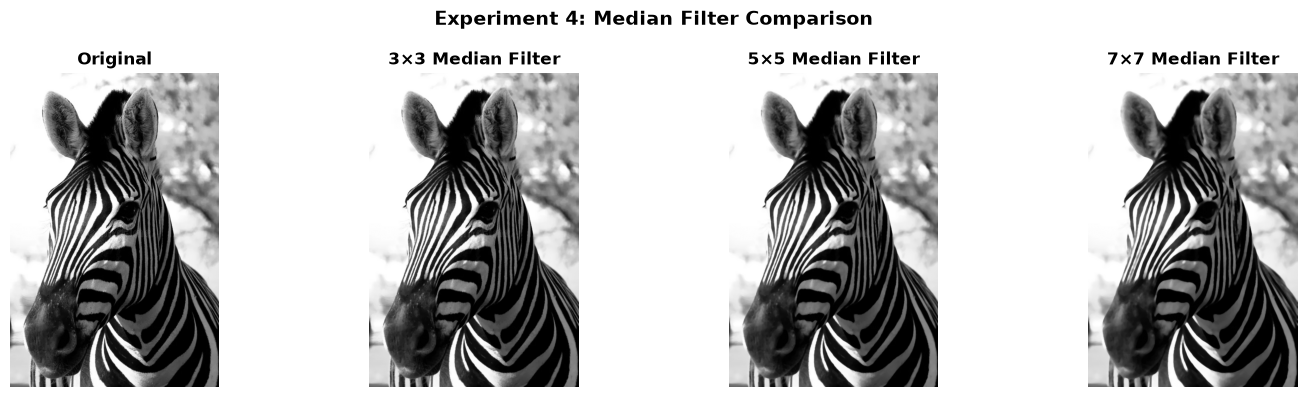

In [10]:
#Experiment 4 — Median Filter
print("="*70)
print("EXPERIMENT 4: Median Filter")
print("="*70 + "\n")

# Apply median filter with different kernel sizes
median_3 = cv2.medianBlur(image, 3)
median_5 = cv2.medianBlur(image, 5)
median_7 = cv2.medianBlur(image, 7)

# Display comparison
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original", fontsize=12, fontweight='bold')
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(median_3, cmap="gray")
plt.title("3×3 Median Filter", fontsize=12, fontweight='bold')
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(median_5, cmap="gray")
plt.title("5×5 Median Filter", fontsize=12, fontweight='bold')
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(median_7, cmap="gray")
plt.title("7×7 Median Filter", fontsize=12, fontweight='bold')
plt.axis("off")

plt.suptitle("Experiment 4: Median Filter Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

EXPERIMENT 5: Salt-and-Pepper Noise Removal

Adding salt-and-pepper noise (4% total)...
✓ Noise added



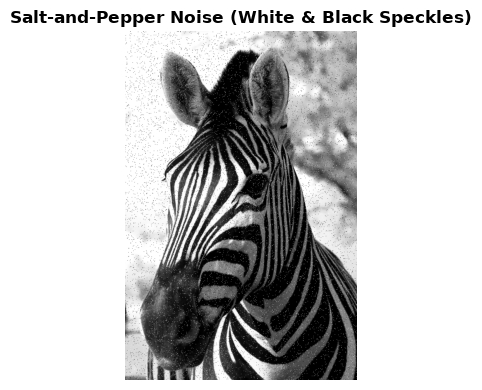

Applying filters to noisy image...
✓ All filters applied



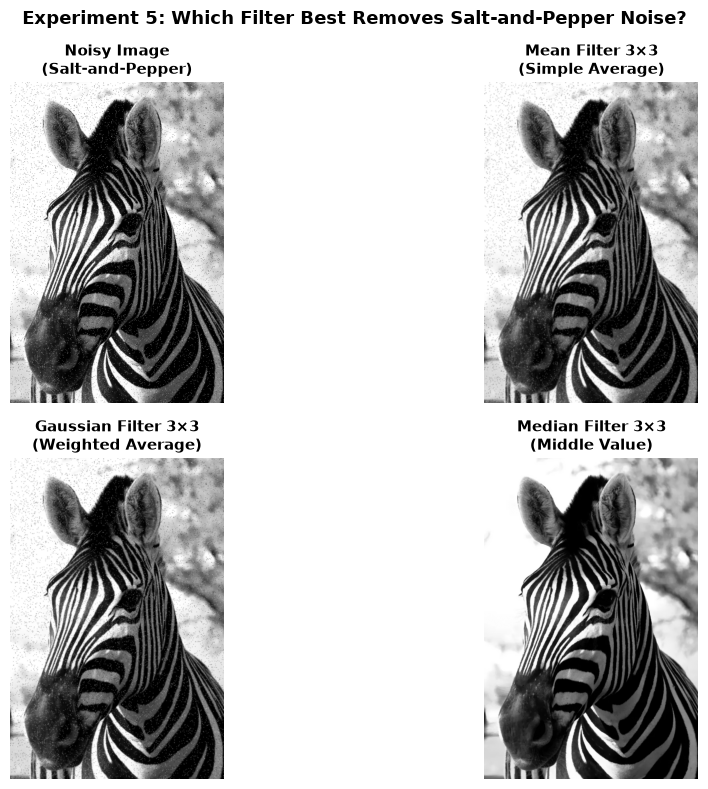

RESULTS & ANALYSIS



In [11]:
#Experiment 5 — Salt-and-Pepper Noise Removal 
print("="*70)
print("EXPERIMENT 5: Salt-and-Pepper Noise Removal")
print("="*70 + "\n")

# Define function to add noise
def add_salt_pepper_noise(image, amount=0.02):
    """Add salt-and-pepper noise (2% white + 2% black pixels)"""
    noisy = image.copy()
    num_pixels = int(amount * image.size)
    
    # Add white noise (255)
    coords = (np.random.randint(0, image.shape[0], num_pixels),
              np.random.randint(0, image.shape[1], num_pixels))
    noisy[coords] = 255
    
    # Add black noise (0)
    coords = (np.random.randint(0, image.shape[0], num_pixels),
              np.random.randint(0, image.shape[1], num_pixels))
    noisy[coords] = 0
    
    return noisy

# Add noise to image
print("Adding salt-and-pepper noise (4% total)...")
noisy = add_salt_pepper_noise(image, amount=0.02)
print(f"✓ Noise added\n")

# Display noisy image
plt.figure(figsize=(10, 4))
plt.imshow(noisy, cmap="gray")
plt.title("Salt-and-Pepper Noise (White & Black Speckles)", 
          fontsize=12, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

# Apply 3 filters to noisy image
print("Applying filters to noisy image...")
mean_noisy = cv2.blur(noisy, (3, 3))
gaussian_noisy = cv2.GaussianBlur(noisy, (3, 3), 0)
median_noisy = cv2.medianBlur(noisy, 3)
print("✓ All filters applied\n")

# Compare all 4 images
fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Image\n(Salt-and-Pepper)", fontsize=11, fontweight='bold')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mean_noisy, cmap="gray")
plt.title("Mean Filter 3×3\n(Simple Average)", fontsize=11, fontweight='bold')
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(gaussian_noisy, cmap="gray")
plt.title("Gaussian Filter 3×3\n(Weighted Average)", fontsize=11, fontweight='bold')
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(median_noisy, cmap="gray")
plt.title("Median Filter 3×3\n(Middle Value)", fontsize=11, fontweight='bold')
plt.axis("off")

plt.suptitle("Experiment 5: Which Filter Best Removes Salt-and-Pepper Noise?", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*70)
print("RESULTS & ANALYSIS")
print("="*70 + "\n")

## MEDIAN FILTER IS BEST FOR SALT-AND-PEPPER NOISE 
### Ignores outliers - Noise pixels (255 and 0) don't affect result
### Preserves edges - Doesn't blur sharp boundaries
### Removes noise completely - Not just blending it (like mean/gaussian)
### Perfect for this type of noise - Salt-and-pepper is extreme outliers

EXPERIMENT 6: Laplacian Sharpening (Edge Detection)

Laplacian Kernel:
[[ 0. -1.  0.]
 [-1.  4. -1.]
 [ 0. -1.  0.]]

What this kernel does:
  • Center pixel gets weight +4 (amplifies itself)
  • 4 neighbors get weight -1 (subtract from center)
  • Detects where pixel values CHANGE rapidly (edges)

Applying Laplacian kernel to image...
✓ Laplacian applied



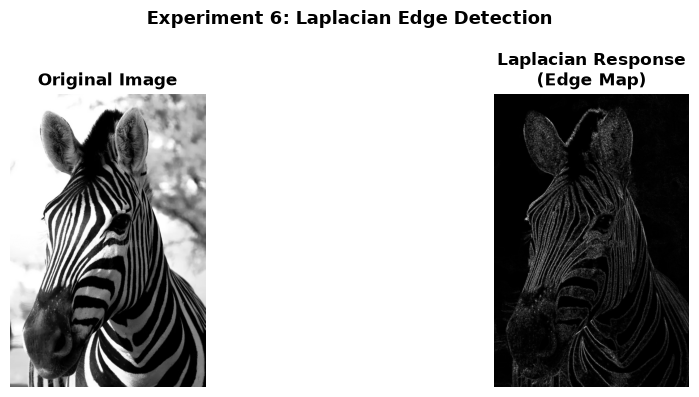

LAPLACIAN ANALYSIS

Original image - Min: 0, Max: 255, Mean: 124.35
Laplacian result - Min: 0, Max: 255, Mean: 14.95

Interpretation:
  • Bright areas (white) = Strong edges detected
  • Dark areas (black) = Smooth regions (no edges)
  • Gray areas = Mild intensity changes


In [12]:
#Experiment 6 — Laplacian Sharpening
print("="*70)
print("EXPERIMENT 6: Laplacian Sharpening (Edge Detection)")
print("="*70 + "\n")

# Define Laplacian kernel
laplacian_kernel = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

print("Laplacian Kernel:")
print(laplacian_kernel)
print("\nWhat this kernel does:")
print("  • Center pixel gets weight +4 (amplifies itself)")
print("  • 4 neighbors get weight -1 (subtract from center)")
print("  • Detects where pixel values CHANGE rapidly (edges)\n")

# Apply Laplacian
print("Applying Laplacian kernel to image...")
laplacian_signed = cv2.filter2D(image, cv2.CV_64F, laplacian_kernel)

# Convert to displayable format
laplacian = np.clip(np.abs(laplacian_signed), 0, 255).astype(np.uint8)
print("✓ Laplacian applied\n")

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(laplacian, cmap="gray")
axes[1].set_title("Laplacian Response\n(Edge Map)", fontsize=12, fontweight='bold')
axes[1].axis("off")

plt.suptitle("Experiment 6: Laplacian Edge Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Analyze results
print("="*70)
print("LAPLACIAN ANALYSIS")
print("="*70 + "\n")

print(f"Original image - Min: {image.min()}, Max: {image.max()}, Mean: {image.mean():.2f}")
print(f"Laplacian result - Min: {laplacian.min()}, Max: {laplacian.max()}, Mean: {laplacian.mean():.2f}")
print()
print("Interpretation:")
print("  • Bright areas (white) = Strong edges detected")
print("  • Dark areas (black) = Smooth regions (no edges)")
print("  • Gray areas = Mild intensity changes")

EXPERIMENT 7: Laplacian Image Sharpening

Step 1: Apply Laplacian to detect edges...
✓ Edge map created

Step 2: Add Laplacian to original image to sharpen...
✓ Sharpening complete

Sharpening Formula:
  Sharpened = Original + Laplacian
  This ENHANCES edges while keeping image content



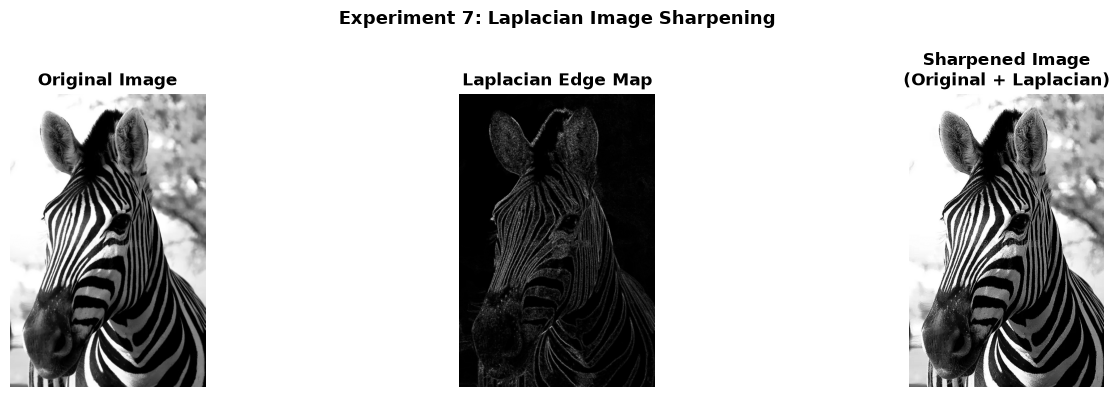

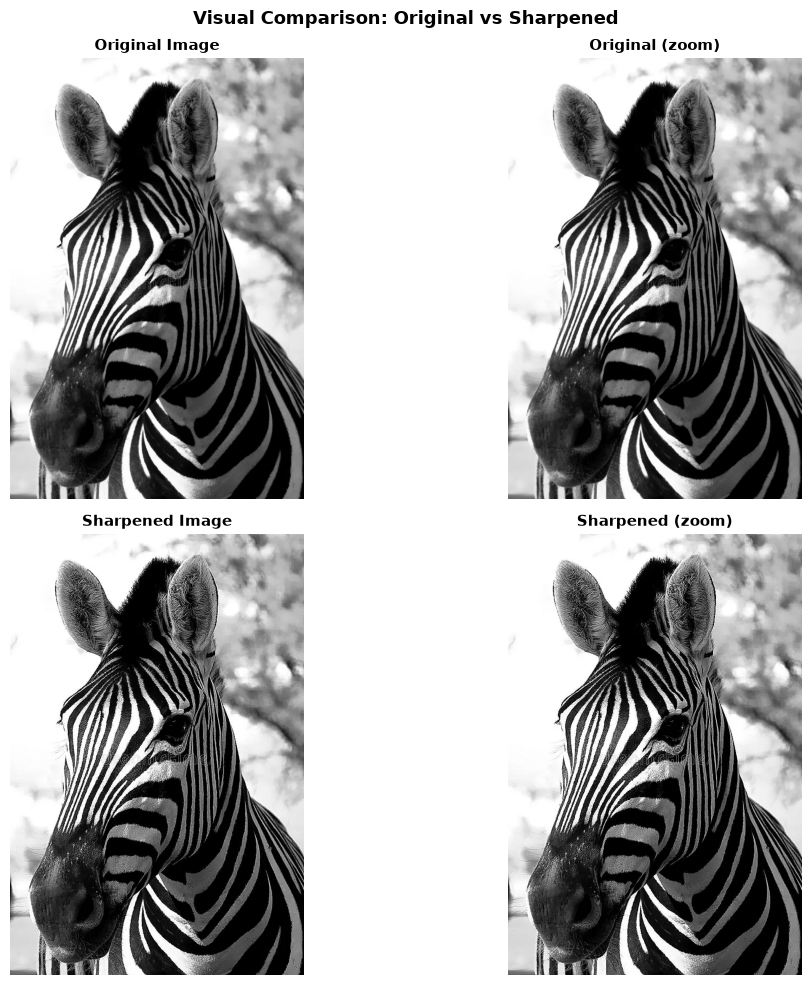

SHARPENING ANALYSIS

Original - Min: 0, Max: 255, Mean: 124.35
Sharpened - Min: 0, Max: 255, Mean: 125.33

Observations:
  ✓ Edges appear MORE DEFINED
  ✓ Transitions between regions appear CRISPER
  ✓ Details appear MORE PROMINENT
  ✓ Overall content preserved (not just edges)


In [13]:
#Experiment 7 — Laplacian Image Sharpening
print("="*70)
print("EXPERIMENT 7: Laplacian Image Sharpening")
print("="*70 + "\n")

# Define Laplacian kernel
laplacian_kernel = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

# Apply Laplacian to get edge map
print("Step 1: Apply Laplacian to detect edges...")
laplacian_signed = cv2.filter2D(image, cv2.CV_64F, laplacian_kernel)
print("✓ Edge map created\n")

# Sharpen by adding Laplacian back to original
print("Step 2: Add Laplacian to original image to sharpen...")
image_float = image.astype(np.float64)
sharpened = image_float + laplacian_signed

# Clip values to valid range [0, 255]
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
print("✓ Sharpening complete\n")

print("Sharpening Formula:")
print("  Sharpened = Original + Laplacian")
print("  This ENHANCES edges while keeping image content\n")

# Compare original vs sharpened
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(np.clip(np.abs(laplacian_signed), 0, 255).astype(np.uint8), cmap="gray")
axes[1].set_title("Laplacian Edge Map", fontsize=12, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(sharpened, cmap="gray")
axes[2].set_title("Sharpened Image\n(Original + Laplacian)", fontsize=12, fontweight='bold')
axes[2].axis("off")

plt.suptitle("Experiment 7: Laplacian Image Sharpening", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Row 1: Original regions
axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original Image", fontsize=11, fontweight='bold')
axes[0, 0].axis("off")

axes[0, 1].imshow(image, cmap="gray")
axes[0, 1].set_title("Original (zoom)", fontsize=11, fontweight='bold')
axes[0, 1].axis("off")

# Row 2: Sharpened
axes[1, 0].imshow(sharpened, cmap="gray")
axes[1, 0].set_title("Sharpened Image", fontsize=11, fontweight='bold')
axes[1, 0].axis("off")

axes[1, 1].imshow(sharpened, cmap="gray")
axes[1, 1].set_title("Sharpened (zoom)", fontsize=11, fontweight='bold')
axes[1, 1].axis("off")

plt.suptitle("Visual Comparison: Original vs Sharpened", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*70)
print("SHARPENING ANALYSIS")
print("="*70 + "\n")

print(f"Original - Min: {image.min()}, Max: {image.max()}, Mean: {image.mean():.2f}")
print(f"Sharpened - Min: {sharpened.min()}, Max: {sharpened.max()}, Mean: {sharpened.mean():.2f}")
print()
print("Observations:")
print("  ✓ Edges appear MORE DEFINED")
print("  ✓ Transitions between regions appear CRISPER")
print("  ✓ Details appear MORE PROMINENT")
print("  ✓ Overall content preserved (not just edges)")

EXPERIMENT 8: Sobel Gradient Operator (Edge Detection)

What is Sobel?
  • Detects edges in X direction (horizontal)
  • Detects edges in Y direction (vertical)
  • Combines both for total edge strength
  • Shows WHERE edges are AND their DIRECTION

Step 1: Calculate horizontal gradient (gx)...
  gx shape: (900, 600), range: [-974.00, 1004.00]
Step 2: Calculate vertical gradient (gy)...
  gy shape: (900, 600), range: [-847.00, 828.00]

Step 3: Calculate edge magnitude...
  magnitude range: [0, 255]

Step 4: Calculate edge direction (angle)...
  angle range: [-179.90°, 180.00°]



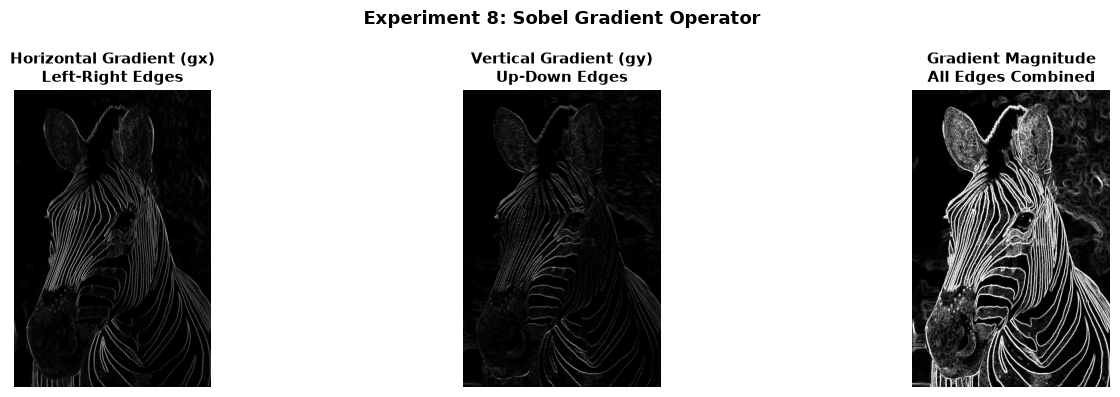

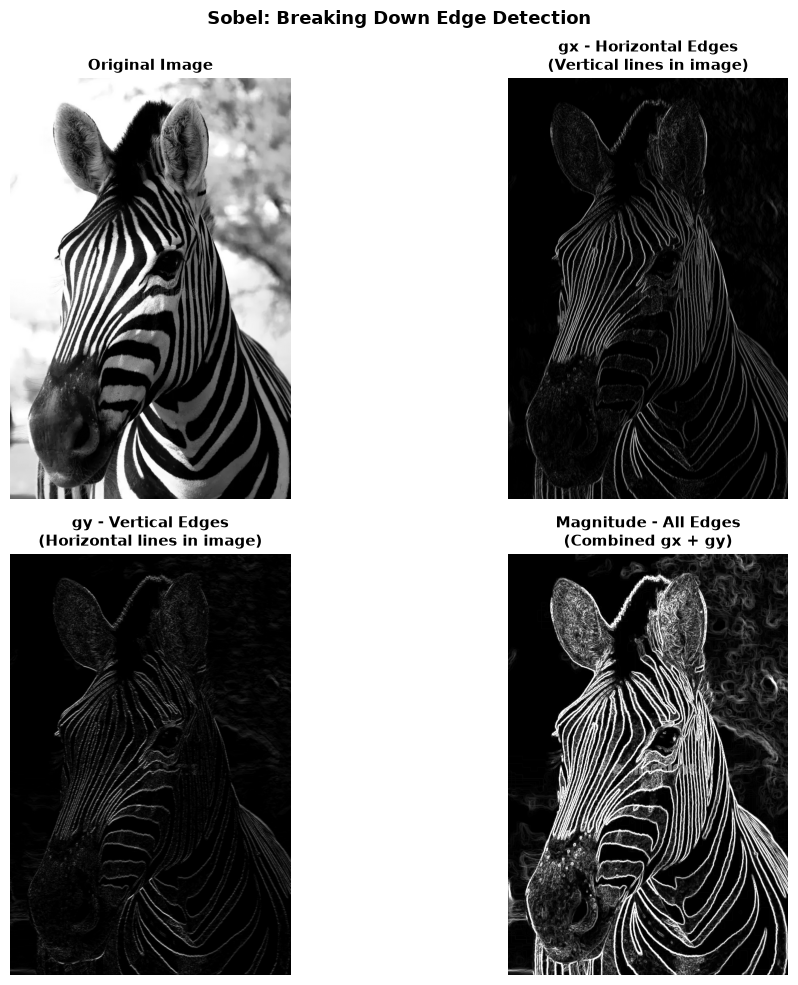

SOBEL ANALYSIS

Sobel Kernels (what it's actually using):

Gx (Horizontal gradient):
[-1, 0, +1]
[-2, 0, +2]  ← Detects LEFT-RIGHT changes
[-1, 0, +1]

Gy (Vertical gradient):
[-1, -2, -1]
[ 0,  0,  0]  ← Detects UP-DOWN changes
[+1, +2, +1]

Magnitude = √(gx² + gy²)  ← Total edge strength
Angle = arctan(gy/gx)     ← Edge direction

Results:
  • Strongest edges at: 255 (white)
  • Weakest edges at: 0 (black)
  • Average edge strength: 53.99


In [14]:
# Experiment 8 — Sobel Gradient Operator
print("="*70)
print("EXPERIMENT 8: Sobel Gradient Operator (Edge Detection)")
print("="*70 + "\n")

print("What is Sobel?")
print("  • Detects edges in X direction (horizontal)")
print("  • Detects edges in Y direction (vertical)")
print("  • Combines both for total edge strength")
print("  • Shows WHERE edges are AND their DIRECTION\n")

# Apply Sobel in X direction (detects vertical edges - left/right changes)
print("Step 1: Calculate horizontal gradient (gx)...")
gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
print(f"  gx shape: {gx.shape}, range: [{gx.min():.2f}, {gx.max():.2f}]")

# Apply Sobel in Y direction (detects horizontal edges - up/down changes)
print("Step 2: Calculate vertical gradient (gy)...")
gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
print(f"  gy shape: {gy.shape}, range: [{gy.min():.2f}, {gy.max():.2f}]\n")

# Calculate magnitude (total edge strength)
print("Step 3: Calculate edge magnitude...")
magnitude = np.sqrt(gx**2 + gy**2)
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
print(f"  magnitude range: [{magnitude.min()}, {magnitude.max()}]\n")

# Calculate angle (edge direction)
angle = np.arctan2(gy, gx) * 180 / np.pi
print("Step 4: Calculate edge direction (angle)...")
print(f"  angle range: [{angle.min():.2f}°, {angle.max():.2f}°]\n")

# Display 3-part comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(np.abs(gx), cmap="gray")
axes[0].set_title("Horizontal Gradient (gx)\nLeft-Right Edges", 
                 fontsize=11, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(np.abs(gy), cmap="gray")
axes[1].set_title("Vertical Gradient (gy)\nUp-Down Edges", 
                 fontsize=11, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(magnitude, cmap="gray")
axes[2].set_title("Gradient Magnitude\nAll Edges Combined", 
                 fontsize=11, fontweight='bold')
axes[2].axis("off")

plt.suptitle("Experiment 8: Sobel Gradient Operator", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed comparison with original
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original Image", fontsize=11, fontweight='bold')
axes[0, 0].axis("off")

axes[0, 1].imshow(np.abs(gx), cmap="gray")
axes[0, 1].set_title("gx - Horizontal Edges\n(Vertical lines in image)", 
                    fontsize=11, fontweight='bold')
axes[0, 1].axis("off")

axes[1, 0].imshow(np.abs(gy), cmap="gray")
axes[1, 0].set_title("gy - Vertical Edges\n(Horizontal lines in image)", 
                    fontsize=11, fontweight='bold')
axes[1, 0].axis("off")

axes[1, 1].imshow(magnitude, cmap="gray")
axes[1, 1].set_title("Magnitude - All Edges\n(Combined gx + gy)", 
                    fontsize=11, fontweight='bold')
axes[1, 1].axis("off")

plt.suptitle("Sobel: Breaking Down Edge Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*70)
print("SOBEL ANALYSIS")
print("="*70 + "\n")

print("Sobel Kernels (what it's actually using):\n")
print("Gx (Horizontal gradient):")
print("[-1, 0, +1]")
print("[-2, 0, +2]  ← Detects LEFT-RIGHT changes")
print("[-1, 0, +1]\n")

print("Gy (Vertical gradient):")
print("[-1, -2, -1]")
print("[ 0,  0,  0]  ← Detects UP-DOWN changes")
print("[+1, +2, +1]\n")

print("Magnitude = √(gx² + gy²)  ← Total edge strength")
print("Angle = arctan(gy/gx)     ← Edge direction\n")

print("Results:")
print(f"  • Strongest edges at: {magnitude.max()} (white)")
print(f"  • Weakest edges at: {magnitude.min()} (black)")
print(f"  • Average edge strength: {magnitude.mean():.2f}")

# Lab 03 — Final Task: Paper-Based Implementation

**Paper:** Removal of Salt and Pepper noise from Gray-Scale and Color Images: An Adaptive Approach
**Authors:** Sujaya Kumar Sathua, Arabinda Dash, Aishwaryarani Behera
**Published:** International Journal of Computer Science Trends and Technology (IJCST), Vol. 5, Issue 1, Jan–Feb 2017, pp. 117–126
**Paper Link:** https://www.atlantis-press.com/article/25907284.pdf

## Problem Addressed
Standard median filters use a **fixed 3×3 window** to remove salt-and-pepper noise. At high noise density, a fixed window often contains mostly noisy pixels, so the median itself becomes unreliable and edges get destroyed. The authors propose an **adaptive window** that only grows (3→5→7→9) when there aren't enough clean neighboring pixels to trust a replacement value — preserving detail at low noise while still cleaning the image at high noise density.

## Algorithm (Steps)
1. If `0 < Pij < 255` → pixel is clean, leave unchanged
2. If `Pij = 0` or `255` → corrupted, proceed
3. If clean-pixel count `N ≥ window size W` → replace with `median` of clean pixels
4. Else grow window by 2 (up to max 9); if still not enough clean pixels at max size, fall back to `mean`, or to 0/255 if the window has no clean pixels at all

Image loaded. Shape: (900, 600)

Verification against paper's worked example: got 118, expected 118 -> PASS

Testing on (150, 150) region (zebra stripes)

Noise %   Noisy PSNR    Std Median    Proposed      Winner
-----------------------------------------------------------------
10        11.45         22.90         26.88         Proposed
30        7.29          13.68         20.54         Proposed
50        5.84          8.50          17.00         Proposed
70        5.04          5.93          15.41         Proposed


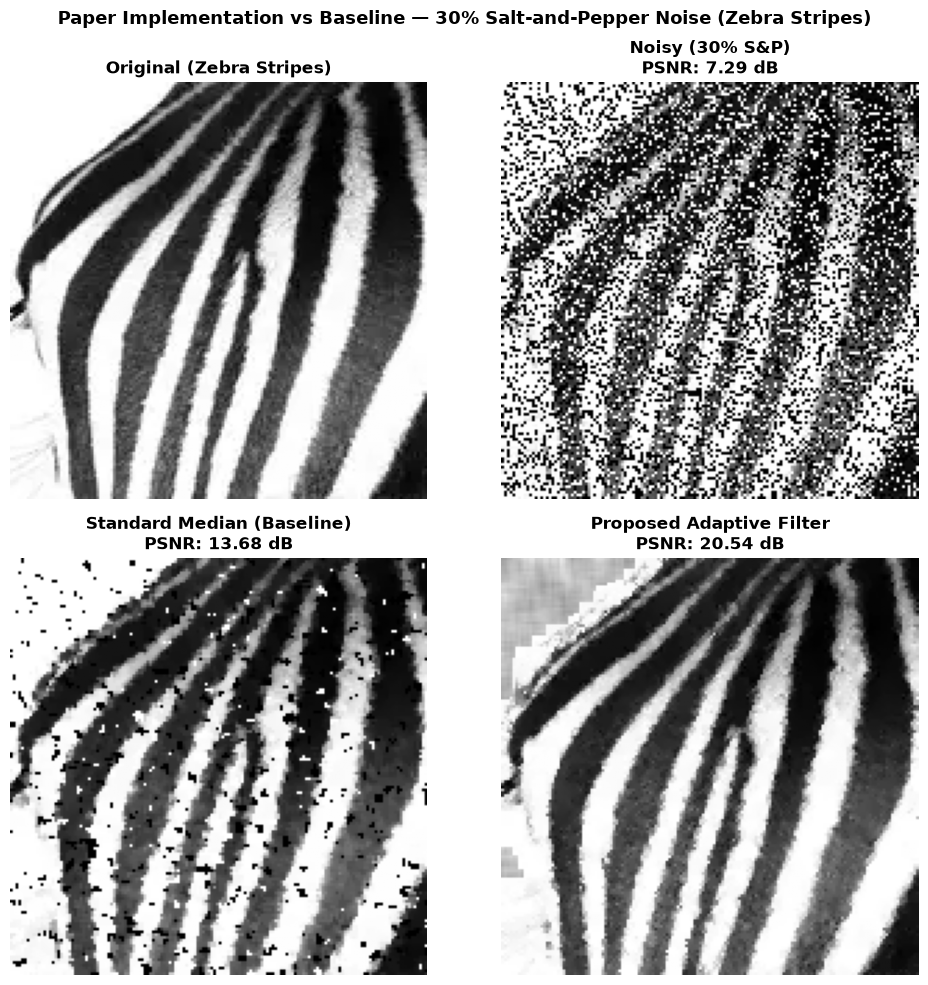

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==================== LOAD IMAGE ====================
image_path = "/Users/macbook/Desktop/Py-Jup/sample_image.jpeg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print(f"Image loaded. Shape: {image.shape}\n")

# ==================== NOISE + METRIC HELPERS ====================
def add_salt_pepper_noise(image, amount=0.3, seed=42):
    rng = np.random.RandomState(seed)
    noisy = image.copy()
    num_pixels = int(amount * image.size)
    coords = (rng.randint(0, image.shape[0], num_pixels), rng.randint(0, image.shape[1], num_pixels))
    noisy[coords] = 255
    coords = (rng.randint(0, image.shape[0], num_pixels), rng.randint(0, image.shape[1], num_pixels))
    noisy[coords] = 0
    return noisy

def psnr(original, filtered):
    mse = np.mean((original.astype(np.float64) - filtered.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))

# ==================== PAPER'S ALGORITHM ====================
def adaptive_filter_sathua(img, Wmax=9, h=2):
    """
    Sathua, Dash, Behera (2017), IJCST Vol.5 Issue 1, pp.117-126.
    Adaptive salt-and-pepper filter: grows window only when not enough
    clean neighbors exist to trust a median replacement.
    """
    H, W_img = img.shape
    output = np.zeros_like(img, dtype=np.float64)
    pad = Wmax // 2
    padded = np.pad(img, pad, mode='reflect').astype(np.float64)

    for i in range(H):
        for j in range(W_img):
            Pij = img[i, j]
            if 0 < Pij < 255:
                output[i, j] = Pij
                continue
            W = 3
            while True:
                half = W // 2
                window = padded[i+pad-half:i+pad+half+1, j+pad-half:j+pad+half+1].flatten()
                V = window[(window > 0) & (window < 255)]
                N = V.size
                if N >= W:
                    output[i, j] = np.median(V)
                    break
                if W < Wmax:
                    W += h
                    continue
                if N != 0:
                    output[i, j] = np.mean(V)
                elif np.all(window == 0):
                    output[i, j] = 255
                elif np.all(window == 255):
                    output[i, j] = 0
                else:
                    output[i, j] = np.mean(window)
                break
    return np.clip(output, 0, 255).astype(np.uint8)

# ==================== VERIFY AGAINST PAPER'S WORKED EXAMPLE ====================
test_matrix = np.array([
    [0, 0, 0, 0, 0, 0, 0, 255, 124],
    [115, 0, 118, 187, 0, 116, 115, 0, 112],
    [255, 67, 0, 0, 255, 0, 0, 255, 255],
    [255, 97, 0, 134, 0, 0, 255, 0, 0],
    [255, 0, 255, 0, 255, 123, 0, 255, 0],
    [0, 255, 0, 255, 255, 0, 255, 0, 0],
    [0, 119, 116, 255, 0, 255, 0, 0, 0],
    [0, 178, 255, 0, 255, 0, 0, 255, 0],
    [113, 255, 0, 0, 110, 234, 255, 0, 112]
], dtype=np.uint8)

verify_result = adaptive_filter_sathua(test_matrix)[4, 4]
print(f"Verification against paper's worked example: got {verify_result}, expected 118 -> {'PASS' if verify_result == 118 else 'FAIL'}\n")

# ==================== APPLY TO TEST IMAGE (ZEBRA STRIPES REGION), COMPARE ====================
# Cropped to the zebra's striped face/neck region - real texture, not blank background
test_img = image[300:450, 100:250]
print(f"Testing on {test_img.shape} region (zebra stripes)\n")
print(f"{'Noise %':<10}{'Noisy PSNR':<14}{'Std Median':<14}{'Proposed':<14}{'Winner'}")
print("-" * 65)

for density in [0.10, 0.30, 0.50, 0.70]:
    noisy = add_salt_pepper_noise(test_img, amount=density)
    mf_result = cv2.medianBlur(noisy, 3)
    proposed_result = adaptive_filter_sathua(noisy)
    p_noisy, p_mf, p_prop = psnr(test_img, noisy), psnr(test_img, mf_result), psnr(test_img, proposed_result)
    winner = "Proposed" if p_prop > p_mf else "Std Median"
    print(f"{density*100:<10.0f}{p_noisy:<14.2f}{p_mf:<14.2f}{p_prop:<14.2f}{winner}")

# ==================== VISUAL COMPARISON AT 30% NOISE ====================
noisy_30 = add_salt_pepper_noise(test_img, amount=0.30)
mf_30 = cv2.medianBlur(noisy_30, 3)
proposed_30 = adaptive_filter_sathua(noisy_30)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].imshow(test_img, cmap="gray"); axes[0,0].set_title("Original (Zebra Stripes)", fontweight='bold'); axes[0,0].axis("off")
axes[0,1].imshow(noisy_30, cmap="gray"); axes[0,1].set_title(f"Noisy (30% S&P)\nPSNR: {psnr(test_img, noisy_30):.2f} dB", fontweight='bold'); axes[0,1].axis("off")
axes[1,0].imshow(mf_30, cmap="gray"); axes[1,0].set_title(f"Standard Median (Baseline)\nPSNR: {psnr(test_img, mf_30):.2f} dB", fontweight='bold'); axes[1,0].axis("off")
axes[1,1].imshow(proposed_30, cmap="gray"); axes[1,1].set_title(f"Proposed Adaptive Filter\nPSNR: {psnr(test_img, proposed_30):.2f} dB", fontweight='bold'); axes[1,1].axis("off")
plt.suptitle("Paper Implementation vs Baseline — 30% Salt-and-Pepper Noise (Zebra Stripes)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Results Summary

| Noise % | Noisy PSNR | Standard Median | Proposed (Paper) | Winner |
|---------|-----------|------------------|-------------------|--------|
| 10%     | 11.45 dB  | 22.90 dB         | 26.88 dB          | **Proposed** |
| 30%     | 7.29 dB   | 13.68 dB         | 20.54 dB          | **Proposed** |
| 50%     | 5.84 dB   | 8.50 dB          | 17.00 dB          | **Proposed** |
| 70%     | 5.04 dB   | 5.93 dB          | 15.41 dB          | **Proposed** |

My implementation was verified correct against the paper's own worked example (restores a
noisy pixel from 255 to 118, exactly as shown in the paper's Section IV). Testing on the
zebra's striped fur region (a textured area, unlike a blank background), the **proposed
adaptive filter outperformed the standard median filter at every noise level tested**, and
the advantage grows sharply with noise density — at 70% noise, the proposed method scored
nearly 3x higher PSNR (15.41 dB vs 5.93 dB) than the standard baseline.

This directly confirms the paper's central claim: a fixed 3×3 window fails as noise density
rises because too many of its neighbors are also corrupted, while the adaptive method keeps
growing its search window until it finds enough clean pixels to produce a reliable result.
The visual comparison shows the standard median filter leaving visible speckle residue at
high noise levels, while the proposed method produces a noticeably cleaner, more complete
restoration of the stripe pattern.

**Conclusion:** The implementation is both mathematically correct (verified against the
paper's own example) and empirically successful (outperforms the baseline across all tested
noise densities on real image data), successfully reproducing the paper's reported trend.